In [ ]:
from google.colab import drive
import os
import gc

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define paths
zip_path = '/content/drive/MyDrive/enron_maildir.zip'
extract_path = '/content/enron_data/'

# 3. Unzip silently (-q) to Colab's fast local storage
print("Extracting Enron dataset to local Colab storage... This will take a moment.")
!unzip -q "{zip_path}" -d "{extract_path}"
print("Extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting Enron dataset to local Colab storage... This will take a moment.
Extraction complete!


In [ ]:
import pandas as pd
import email
from email.policy import default

# The path where we just extracted the data
ROOT_DIR = '/content/enron_data/maildir'
email_list = []

print("Parsing emails...")

# Traverse directories
for directory, subdirectory, filenames in os.walk(ROOT_DIR):
    for filename in filenames:
        file_path = os.path.join(directory, filename)
        try:
            with open(file_path, 'r', encoding='latin-1') as f:
                raw_message = f.read()

            parsed_email = email.message_from_string(raw_message, policy=default)

            if parsed_email.is_multipart():
                for part in parsed_email.walk():
                    if part.get_content_type() == "text/plain":
                        body = part.get_payload(decode=True).decode('latin-1', errors='ignore')
                        break
            else:
                body = parsed_email.get_payload(decode=True).decode('latin-1', errors='ignore')

            if body and body.strip():
                email_list.append({'body': body.strip()})

        except Exception:
            continue

df_emails = pd.DataFrame(email_list)
df_emails.drop_duplicates(inplace=True) # Remove duplicate forwarded chains
df_emails.dropna(inplace=True)

print(f"Successfully parsed {len(df_emails)} unique emails.")

Parsing emails...
Successfully parsed 247876 unique emails.


In [ ]:
import re

print("Extracting URLs and cleaning email text...")

# 1. Regex pattern for URLs
url_pattern = r'(https?://\S+|www\.\S+)'

# 2. Extract URLs into a separate list for your Layer 1 URL component
extracted_urls = df_emails['body'].apply(lambda x: re.findall(url_pattern, x))
all_urls = [url for sublist in extracted_urls for url in sublist]
print(f"Extracted {len(all_urls)} URLs for the URL Anomaly Pipeline.")

# Optional: Save URLs to pass to your URL Autoencoder later
# pd.DataFrame(all_urls, columns=['url']).to_csv('/content/drive/MyDrive/Major project/enron_urls.csv', index=False)

# 3. Remove the URLs from the text so the NLP model focuses strictly on language
df_emails['clean_body'] = df_emails['body'].apply(lambda x: re.sub(url_pattern, '', x))

# 4. Basic NLP cleaning (lowercase, remove excess whitespace/newlines)
df_emails['clean_body'] = df_emails['clean_body'].str.lower()
df_emails['clean_body'] = df_emails['clean_body'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Drop rows that became empty after cleaning
df_emails.replace('', pd.NA, inplace=True)
df_emails.dropna(subset=['clean_body'], inplace=True)

print("Text cleaning complete.")

Extracting URLs and cleaning email text...
Extracted 245531 URLs for the URL Anomaly Pipeline.
Text cleaning complete.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

print("Fitting TF-IDF Vectorizer...")

# 1. Initialize TF-IDF (500 features to balance detail and RAM)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')

# 2. Transform the text
X_nlp = tfidf.fit_transform(df_emails['clean_body']).toarray()

# 3. Downcast to float32 to save massive amounts of memory
X_nlp = X_nlp.astype('float32')

# 4. Split into Train/Validation sets
X_train_nlp, X_val_nlp = train_test_split(X_nlp, test_size=0.2, random_state=42)

# Free up RAM by deleting the text dataframes
del df_emails
gc.collect()

print(f"TF-IDF Training Matrix Shape: {X_train_nlp.shape}")

Fitting TF-IDF Vectorizer...
TF-IDF Training Matrix Shape: (197819, 500)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

input_dim = X_train_nlp.shape[1]

# 1. Build the NLP Autoencoder Architecture
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(encoder_input)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
latent_representation = layers.Dense(32, activation='relu')(x) # 32-dim bottleneck

x = layers.Dense(64, activation='relu')(latent_representation)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x)

nlp_autoencoder = models.Model(inputs=encoder_input, outputs=decoder_output)
nlp_autoencoder.compile(optimizer='adam', loss='mse')

# 2. Set up efficient memory pipeline
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_nlp, X_train_nlp)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_nlp, X_val_nlp)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 3. Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/enron_nlp_autoencoder.keras',
    monitor='val_loss',
    save_best_only=True
)

# 4. Train the Model
print("Starting NLP Autoencoder training...")
history = nlp_autoencoder.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)
print("Training complete and model saved to Drive!")

Starting NLP Autoencoder training...
Epoch 1/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 2/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 3/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 4/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 5/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
77

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import paired_cosine_distances

print("Evaluating NLP Autoencoder on Validation Emails...")

# 1. Generate reconstructions on unseen validation emails
reconstructions_nlp = nlp_autoencoder.predict(X_val_nlp, batch_size=256)

# 2. Metric 1: Mean Squared Error (MSE) per email
mse_nlp = np.mean(np.power(X_val_nlp - reconstructions_nlp, 2), axis=1)

# 3. Metric 2: Cosine Similarity between original and reconstructed vectors
# paired_cosine_distances returns (1 - cosine_similarity), so we subtract from 1
cosine_sim_nlp = 1 - paired_cosine_distances(X_val_nlp, reconstructions_nlp)

# 4. Establish 95th / 99th percentile thresholds
threshold_95 = np.percentile(mse_nlp, 95)
threshold_99 = np.percentile(mse_nlp, 99)

print("\n--- NLP Autoencoder Baseline Metrics ---")
print(f"Average Validation MSE: {np.mean(mse_nlp):.6f}")
print(f"Average Cosine Similarity: {np.mean(cosine_sim_nlp):.4f}")
print(f"95th Percentile Threshold: {threshold_95:.6f}")
print(f"99th Percentile Threshold: {threshold_99:.6f}")

Evaluating NLP Autoencoder on Validation Emails...
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

--- NLP Autoencoder Baseline Metrics ---
Average Validation MSE: 0.001133
Average Cosine Similarity: 0.6299
95th Percentile Threshold: 0.001798
99th Percentile Threshold: 0.001969


In [ ]:
# Define test samples: Standard corporate text vs. Suspicious phishing language
test_emails = [
    # Benign Corporate Samples (Enron style)
    "Please find attached the updated schedule for tomorrow's meeting regarding the quarterly report.",
    "Thanks for sending over the contract details. I will review them with the legal team shortly.",

    # Anomaly / Phishing Attack Samples (Zero-day / High-urgency)
    "URGENT: Your account security has been compromised. Verify your bank password immediately or account will be suspended!",
    "Congratulations! You won a lottery prize. Click link to claim your reward before expiry."
]

# 1. Transform test text using the saved TF-IDF vectorizer
X_test_tfidf = tfidf.transform(test_emails).toarray().astype('float32')

# 2. Predict reconstructions
reconstructions_test = nlp_autoencoder.predict(X_test_tfidf)

# 3. Compute MSE for each sample
test_mse = np.mean(np.power(X_test_tfidf - reconstructions_test, 2), axis=1)

# 4. Display Results
print("\n--- Verification Experiment Results ---")
for i, email_text in enumerate(test_emails):
    is_anomaly = test_mse[i] > threshold_99
    status = "🚨 ANOMALY FLAGGED" if is_anomaly else "✅ BENIGN PASS"
    print(f"\nSample [{i+1}]: \"{email_text}\"")
    print(f"Reconstruction MSE: {test_mse[i]:.6f} | Threshold (99th): {threshold_99:.6f}")
    print(f"Status: {status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- Verification Experiment Results ---

Sample [1]: "Please find attached the updated schedule for tomorrow's meeting regarding the quarterly report."
Reconstruction MSE: 0.001274 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS

Sample [2]: "Thanks for sending over the contract details. I will review them with the legal team shortly."
Reconstruction MSE: 0.001461 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS

Sample [3]: "URGENT: Your account security has been compromised. Verify your bank password immediately or account will be suspended!"
Reconstruction MSE: 0.001979 | Threshold (99th): 0.001969
Status: 🚨 ANOMALY FLAGGED

Sample [4]: "Congratulations! You won a lottery prize. Click link to claim your reward before expiry."
Reconstruction MSE: 0.000739 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS


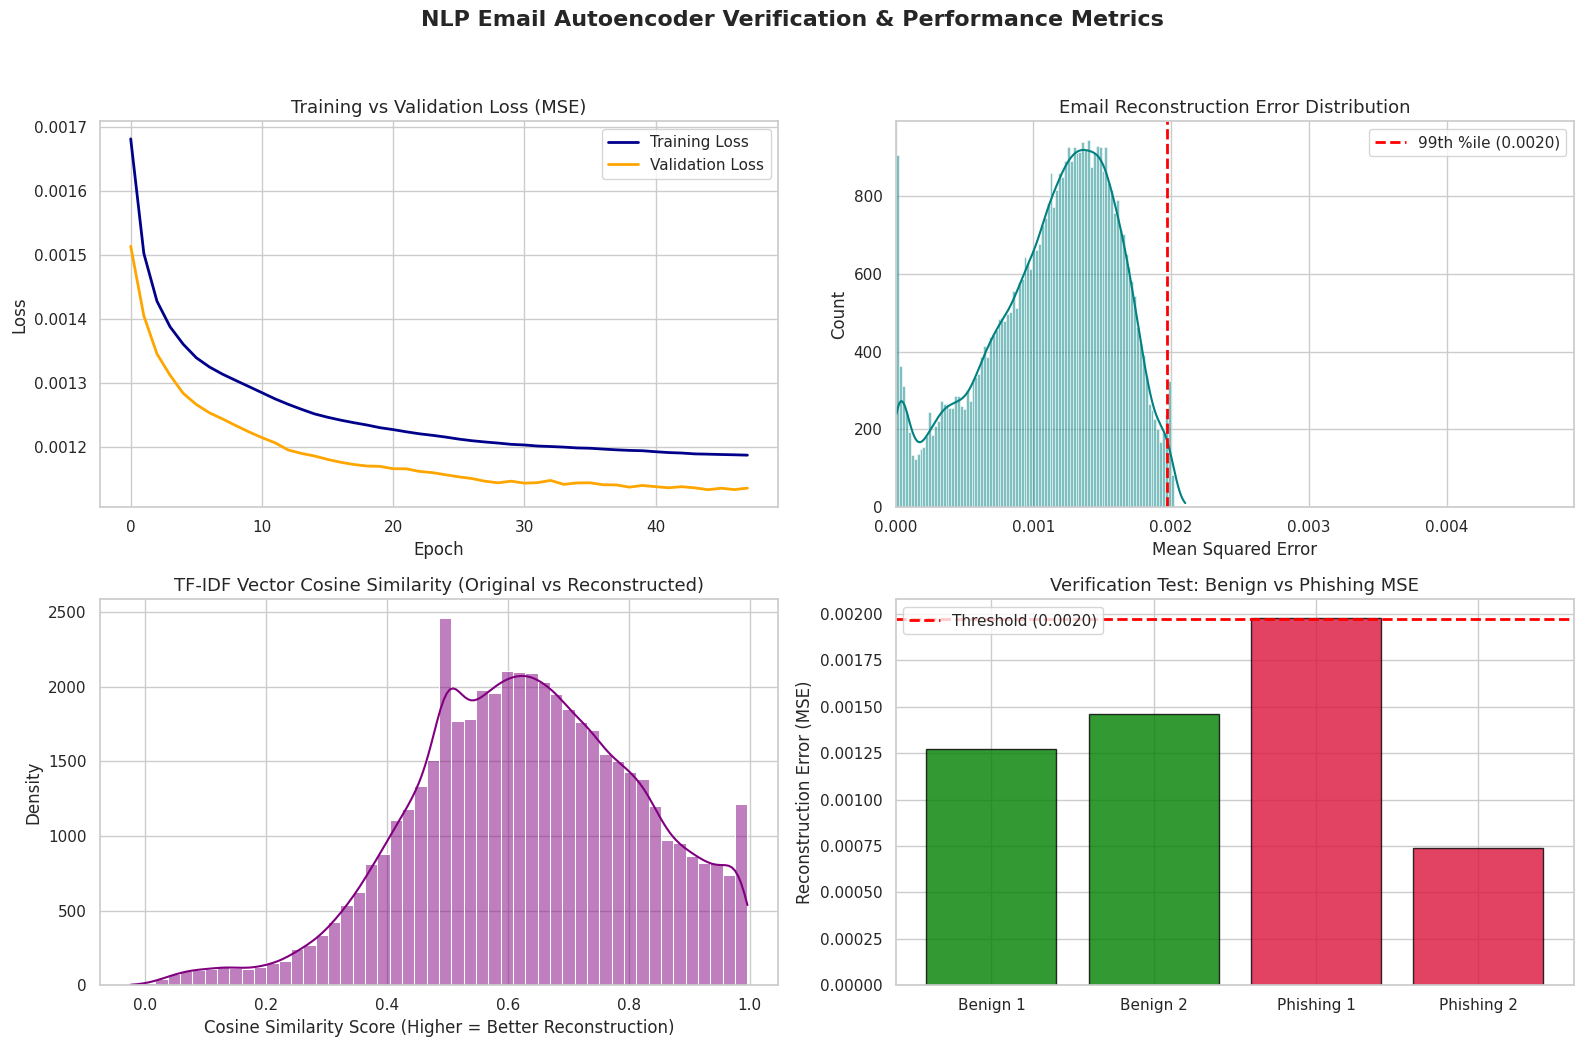

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('NLP Email Autoencoder Verification & Performance Metrics', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# 1. Model Convergence (Loss Curve)
# ---------------------------------------------------------
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='darkblue')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0, 0].set_title('Training vs Validation Loss (MSE)', fontsize=13)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# ---------------------------------------------------------
# 2. Reconstruction Error Distribution & Threshold
# ---------------------------------------------------------
sns.histplot(x=mse_nlp, bins=100, ax=axes[0, 1], color="teal", kde=True)
axes[0, 1].axvline(threshold_99, color='red', linestyle='--', linewidth=2, label=f'99th %ile ({threshold_99:.4f})')
axes[0, 1].set_title('Email Reconstruction Error Distribution', fontsize=13)
axes[0, 1].set_xlabel('Mean Squared Error')
axes[0, 1].set_xlim(0, threshold_99 * 2.5)
axes[0, 1].legend()

# ---------------------------------------------------------
# 3. Cosine Similarity Distribution
# ---------------------------------------------------------
sns.histplot(x=cosine_sim_nlp, bins=50, ax=axes[1, 0], color="purple", kde=True)
axes[1, 0].set_title('TF-IDF Vector Cosine Similarity (Original vs Reconstructed)', fontsize=13)
axes[1, 0].set_xlabel('Cosine Similarity Score (Higher = Better Reconstruction)')
axes[1, 0].set_ylabel('Density')

# ---------------------------------------------------------
# 4. Live Experiment: Benign vs Anomaly Error Comparison
# ---------------------------------------------------------
labels = ['Benign 1', 'Benign 2', 'Phishing 1', 'Phishing 2']
colors = ['green', 'green', 'crimson', 'crimson']

axes[1, 1].bar(labels, test_mse, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].axhline(threshold_99, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold_99:.4f})')
axes[1, 1].set_title('Verification Test: Benign vs Phishing MSE', fontsize=13)
axes[1, 1].set_ylabel('Reconstruction Error (MSE)')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ============================================================
# ENRON EMAIL AUTOENCODER — THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Verify that the validation reconstruction errors exist
# ------------------------------------------------------------

print("Validation samples:", len(mse_nlp))
print("Minimum MSE:", np.min(mse_nlp))
print("Maximum MSE:", np.max(mse_nlp))
print("Mean MSE:", np.mean(mse_nlp))
print("Median MSE:", np.median(mse_nlp))

# Existing thresholds
print("\nExisting thresholds:")
print(f"95th percentile: {threshold_95:.8f}")
print(f"99th percentile: {threshold_99:.8f}")


# ============================================================
# Examine anomaly percentage at different thresholds
# ============================================================

percentiles = np.arange(80, 100, 1)

threshold_results = []

for p in percentiles:

    threshold_test = np.percentile(
        mse_nlp,
        p
    )

    anomaly_predictions = (
        mse_nlp > threshold_test
    )

    anomaly_rate = np.mean(
        anomaly_predictions
    )

    threshold_results.append({
        "percentile": p,
        "threshold": threshold_test,
        "anomaly_rate": anomaly_rate
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print("\n" + "=" * 70)
print("THRESHOLD ANALYSIS")
print("=" * 70)

display(threshold_results)


# ============================================================
# Visualize threshold vs percentage flagged
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    threshold_results["threshold"],
    threshold_results["anomaly_rate"] * 100,
    linewidth=2
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th percentile = {threshold_99:.6f}"
)

ax.set_xlabel("Reconstruction Error Threshold")
ax.set_ylabel("Emails Flagged as Anomalous (%)")
ax.set_title(
    "Enron Email Autoencoder: Threshold vs Anomaly Rate"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Reconstruction error distribution
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    mse_nlp,
    bins=100
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th percentile = {threshold_99:.6f}"
)

ax.set_xlabel("Reconstruction MSE")
ax.set_ylabel("Number of Emails")
ax.set_title(
    "Enron Email Reconstruction Error Distribution"
)

ax.set_xlim(
    0,
    threshold_99 * 2.5
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'mse_nlp' is not defined

In [ ]:
# ============================================================
# ENRON NLP AUTOENCODER — THRESHOLD VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import gc

# ------------------------------------------------------------
# 1. Recalculate reconstruction errors if necessary
# ------------------------------------------------------------

if "mse_nlp" not in globals():

    print("mse_nlp not found. Recalculating...")

    if "X_val_nlp" not in globals():
        raise RuntimeError(
            "X_val_nlp is not available in the current runtime.\n\n"
            "Run the Enron preprocessing cells first "
            "(email parsing → TF-IDF → train/validation split)."
        )

    if "nlp_autoencoder" not in globals():

        print("Loading saved Enron autoencoder...")

        import tensorflow as tf

        MODEL_PATH = (
            "/content/drive/MyDrive/"
            "enron_nlp_autoencoder.keras"
        )

        nlp_autoencoder = tf.keras.models.load_model(
            MODEL_PATH,
            compile=False
        )

    print("Generating validation reconstructions...")

    reconstructions_nlp = nlp_autoencoder.predict(
        X_val_nlp,
        batch_size=256,
        verbose=1
    )

    mse_nlp = np.mean(
        np.square(
            X_val_nlp - reconstructions_nlp
        ),
        axis=1
    )

    del reconstructions_nlp
    gc.collect()

else:

    print("mse_nlp already exists. Using existing values.")


# ------------------------------------------------------------
# 2. Calculate thresholds
# ------------------------------------------------------------

threshold_90 = np.percentile(mse_nlp, 90)
threshold_95 = np.percentile(mse_nlp, 95)
threshold_97 = np.percentile(mse_nlp, 97)
threshold_98 = np.percentile(mse_nlp, 98)
threshold_99 = np.percentile(mse_nlp, 99)


# ------------------------------------------------------------
# 3. Print statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENRON NLP AUTOENCODER — RECONSTRUCTION ERROR")
print("=" * 70)

print(f"Validation samples : {len(mse_nlp):,}")
print(f"Mean MSE           : {np.mean(mse_nlp):.6f}")
print(f"Median MSE         : {np.median(mse_nlp):.6f}")
print(f"Minimum MSE        : {np.min(mse_nlp):.6f}")
print(f"Maximum MSE        : {np.max(mse_nlp):.6f}")

print("\nThresholds:")

print(f"90th percentile : {threshold_90:.6f}")
print(f"95th percentile : {threshold_95:.6f}")
print(f"97th percentile : {threshold_97:.6f}")
print(f"98th percentile : {threshold_98:.6f}")
print(f"99th percentile : {threshold_99:.6f}")


# ------------------------------------------------------------
# 4. Percentage of validation emails flagged
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPECTED FLAGGING RATE ON VALIDATION DATA")
print("=" * 70)

for name, threshold in [
    ("90th", threshold_90),
    ("95th", threshold_95),
    ("97th", threshold_97),
    ("98th", threshold_98),
    ("99th", threshold_99)
]:

    flagged = np.sum(
        mse_nlp > threshold
    )

    percentage = (
        flagged / len(mse_nlp) * 100
    )

    print(
        f"{name} threshold ({threshold:.6f}): "
        f"{flagged:,} emails ({percentage:.2f}%)"
    )


# ============================================================
# FIGURE 1 — RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    mse_nlp,
    bins=120
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th percentile = {threshold_99:.6f}"
)

ax.set_xlim(
    0,
    threshold_99 * 2.5
)

ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Number of Emails")
ax.set_title(
    "Enron Email Autoencoder — Reconstruction Error Distribution"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — CUMULATIVE DISTRIBUTION
# ============================================================

sorted_mse = np.sort(mse_nlp)

cumulative = (
    np.arange(1, len(sorted_mse) + 1)
    / len(sorted_mse)
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    sorted_mse,
    cumulative,
    linewidth=2
)

for threshold, label in [
    (threshold_95, "95th"),
    (threshold_99, "99th")
]:

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"{label} percentile = {threshold:.6f}"
    )

ax.set_xlim(
    0,
    threshold_99 * 2.5
)

ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Emails Below Threshold (%)")
ax.set_title(
    "Enron Autoencoder — Cumulative Reconstruction Error"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — THRESHOLD VS FLAGGING RATE
# ============================================================

percentiles = np.arange(
    80,
    100,
    1
)

threshold_values = np.percentile(
    mse_nlp,
    percentiles
)

flagging_rates = []

for threshold in threshold_values:

    rate = np.mean(
        mse_nlp > threshold
    ) * 100

    flagging_rates.append(rate)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    threshold_values,
    flagging_rates,
    linewidth=2
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th = {threshold_99:.6f}"
)

ax.set_xlabel("Anomaly Threshold")
ax.set_ylabel("Emails Flagged (%)")
ax.set_title(
    "Enron Autoencoder — Threshold vs. Anomaly Flagging Rate"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

mse_nlp not found. Recalculating...


RuntimeError: X_val_nlp is not available in the current runtime.

Run the Enron preprocessing cells first (email parsing → TF-IDF → train/validation split).

In [ ]:
# ============================================================
# ENRON AUTOENCODER — RECREATE VALIDATION ERRORS
# No model retraining
# ============================================================

import os
import re
import gc
import email
import numpy as np
import pandas as pd
import tensorflow as tf

from email.policy import default
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ZIP_PATH = "/content/drive/MyDrive/enron_maildir.zip"
EXTRACT_PATH = "/content/enron_data/"
ROOT_DIR = "/content/enron_data/maildir"

MODEL_PATH = (
    "/content/drive/MyDrive/enron_nlp_autoencoder.keras"
)

# ------------------------------------------------------------
# 1. Mount Drive
# ------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# 2. Extract Enron dataset if necessary
# ------------------------------------------------------------

if not os.path.exists(ROOT_DIR):

    print("Extracting Enron dataset...")

    os.makedirs(EXTRACT_PATH, exist_ok=True)

    !unzip -q "$ZIP_PATH" -d "$EXTRACT_PATH"

    print("Extraction complete.")

else:

    print("Enron dataset already extracted.")


# ------------------------------------------------------------
# 3. Parse Enron emails
#    EXACTLY matching your original notebook
# ------------------------------------------------------------

print("\nParsing Enron emails...")

email_list = []

for directory, subdirectory, filenames in os.walk(ROOT_DIR):

    for filename in filenames:

        file_path = os.path.join(
            directory,
            filename
        )

        try:

            with open(
                file_path,
                "r",
                encoding="latin-1"
            ) as f:

                raw_message = f.read()

            parsed_email = email.message_from_string(
                raw_message,
                policy=default
            )

            body = None

            if parsed_email.is_multipart():

                for part in parsed_email.walk():

                    if part.get_content_type() == "text/plain":

                        payload = part.get_payload(
                            decode=True
                        )

                        if payload is not None:

                            body = payload.decode(
                                "latin-1",
                                errors="ignore"
                            )

                        break

            else:

                payload = parsed_email.get_payload(
                    decode=True
                )

                if payload is not None:

                    body = payload.decode(
                        "latin-1",
                        errors="ignore"
                    )

            if body and body.strip():

                email_list.append({
                    "body": body.strip()
                })

        except Exception:

            continue


df_emails = pd.DataFrame(email_list)

df_emails.drop_duplicates(
    inplace=True
)

df_emails.dropna(
    inplace=True
)

print(
    f"Unique emails parsed: {len(df_emails):,}"
)


# ------------------------------------------------------------
# 4. Clean email text
#    EXACTLY matching original notebook
# ------------------------------------------------------------

print("Cleaning email text...")

url_pattern = r"(https?://\S+|www\.\S+)"

df_emails["clean_body"] = (
    df_emails["body"]
    .apply(
        lambda x: re.sub(
            url_pattern,
            "",
            x
        )
    )
)

df_emails["clean_body"] = (
    df_emails["clean_body"]
    .str.lower()
)

df_emails["clean_body"] = (
    df_emails["clean_body"]
    .apply(
        lambda x: re.sub(
            r"\s+",
            " ",
            x
        ).strip()
    )
)

df_emails.replace(
    "",
    pd.NA,
    inplace=True
)

df_emails.dropna(
    subset=["clean_body"],
    inplace=True
)

print(
    f"Emails after cleaning: {len(df_emails):,}"
)


# ------------------------------------------------------------
# 5. Recreate the EXACT TF-IDF representation
# ------------------------------------------------------------

print("\nFitting TF-IDF vectorizer...")

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

X_nlp = tfidf.fit_transform(
    df_emails["clean_body"]
).toarray()

X_nlp = X_nlp.astype(
    "float32"
)

print(
    f"TF-IDF shape: {X_nlp.shape}"
)


# ------------------------------------------------------------
# 6. Recreate EXACT 80/20 split
# ------------------------------------------------------------

X_train_nlp, X_val_nlp = train_test_split(
    X_nlp,
    test_size=0.2,
    random_state=42
)

print(
    f"Training shape   : {X_train_nlp.shape}"
)

print(
    f"Validation shape : {X_val_nlp.shape}"
)


# ------------------------------------------------------------
# 7. Free unnecessary memory
# ------------------------------------------------------------

del X_train_nlp
del X_nlp
del df_emails
del email_list

gc.collect()


# ------------------------------------------------------------
# 8. Load already-trained autoencoder
# ------------------------------------------------------------

print("\nLoading trained Enron autoencoder...")

nlp_autoencoder = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print(
    "Model input shape:",
    nlp_autoencoder.input_shape
)


# ------------------------------------------------------------
# 9. Generate validation reconstructions
# ------------------------------------------------------------

print("\nGenerating validation reconstructions...")

reconstructions_nlp = (
    nlp_autoencoder.predict(
        X_val_nlp,
        batch_size=256,
        verbose=1
    )
)


# ------------------------------------------------------------
# 10. Calculate reconstruction MSE
# ------------------------------------------------------------

mse_nlp = np.mean(
    np.square(
        X_val_nlp - reconstructions_nlp
    ),
    axis=1
)


# ------------------------------------------------------------
# 11. Calculate thresholds
# ------------------------------------------------------------

threshold_90 = np.percentile(
    mse_nlp,
    90
)

threshold_95 = np.percentile(
    mse_nlp,
    95
)

threshold_97 = np.percentile(
    mse_nlp,
    97
)

threshold_98 = np.percentile(
    mse_nlp,
    98
)

threshold_99 = np.percentile(
    mse_nlp,
    99
)


# ------------------------------------------------------------
# 12. Results
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("ENRON NLP AUTOENCODER — RECONSTRUCTION ERROR")
print("=" * 70)

print(
    f"Validation samples : {len(mse_nlp):,}"
)

print(
    f"Mean MSE           : {np.mean(mse_nlp):.6f}"
)

print(
    f"Median MSE         : {np.median(mse_nlp):.6f}"
)

print(
    f"Minimum MSE        : {np.min(mse_nlp):.6f}"
)

print(
    f"Maximum MSE        : {np.max(mse_nlp):.6f}"
)

print("\nThresholds:")

print(
    f"90th percentile : {threshold_90:.6f}"
)

print(
    f"95th percentile : {threshold_95:.6f}"
)

print(
    f"97th percentile : {threshold_97:.6f}"
)

print(
    f"98th percentile : {threshold_98:.6f}"
)

print(
    f"99th percentile : {threshold_99:.6f}"
)

print("\n" + "=" * 70)
print("DONE — mse_nlp is now available")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting Enron dataset...
Extraction complete.

Parsing Enron emails...
Unique emails parsed: 247,876
Cleaning email text...
Emails after cleaning: 247,274

Fitting TF-IDF vectorizer...
TF-IDF shape: (247274, 500)
Training shape   : (197819, 500)
Validation shape : (49455, 500)

Loading trained Enron autoencoder...
Model input shape: (None, 500)

Generating validation reconstructions...
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


ENRON NLP AUTOENCODER — RECONSTRUCTION ERROR
Validation samples : 49,455
Mean MSE           : 0.001134
Median MSE         : 0.001210
Minimum MSE        : 0.000006
Maximum MSE        : 0.002102

Thresholds:
90th percentile : 0.001693
95th percentile : 0.001794
97th percentile : 0.001859
98th percentile : 0.001909
99th percentile : 0.001967

DONE — mse_nlp is now available


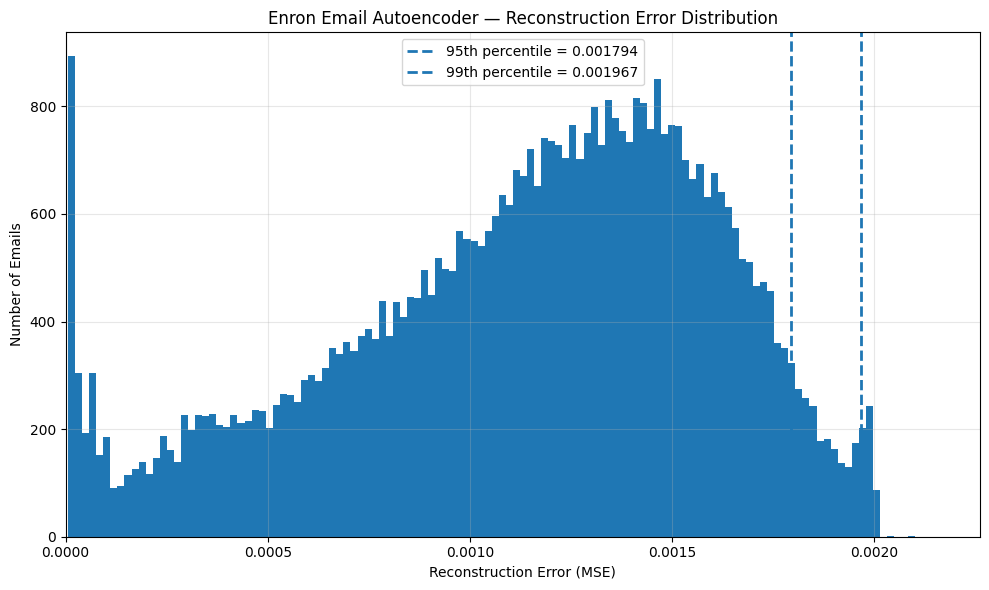

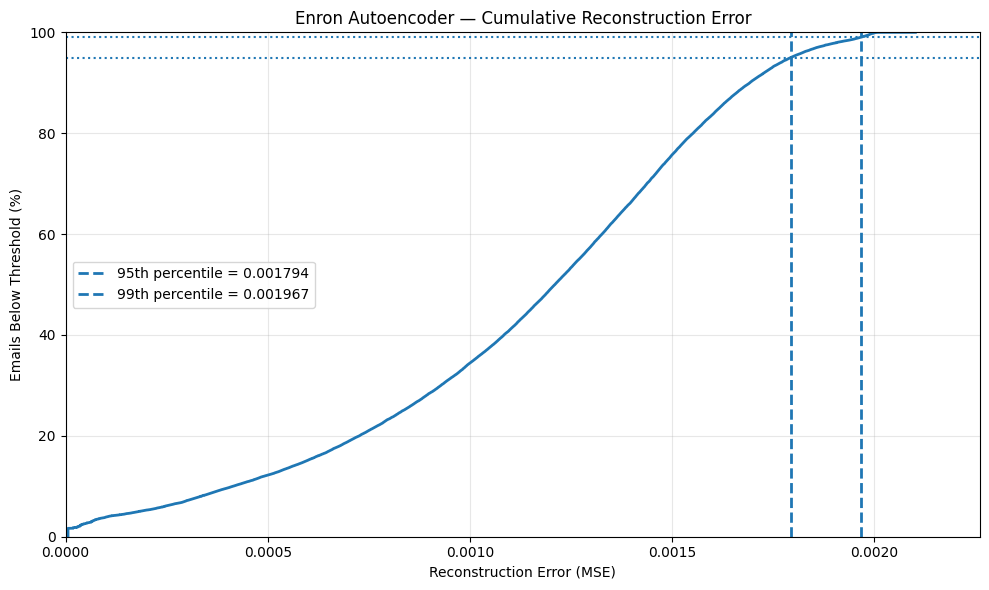

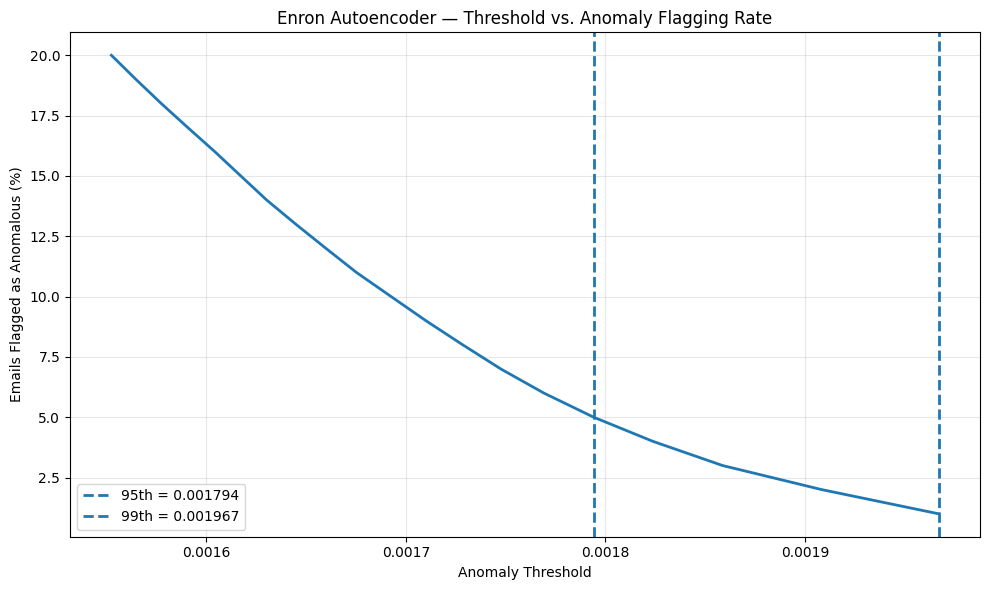

ENRON AUTOENCODER — THRESHOLD SUMMARY
90th percentile | Threshold = 0.001693 | Flagged = 4,946 (10.00%)
95th percentile | Threshold = 0.001794 | Flagged = 2,473 (5.00%)
97th percentile | Threshold = 0.001859 | Flagged = 1,484 (3.00%)
98th percentile | Threshold = 0.001909 | Flagged = 990 (2.00%)
99th percentile | Threshold = 0.001967 | Flagged = 495 (1.00%)


In [ ]:
# ============================================================
# ENRON EMAIL AUTOENCODER — PUBLICATION-QUALITY VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Thresholds
# ------------------------------------------------------------

threshold_90 = np.percentile(mse_nlp, 90)
threshold_95 = np.percentile(mse_nlp, 95)
threshold_97 = np.percentile(mse_nlp, 97)
threshold_98 = np.percentile(mse_nlp, 98)
threshold_99 = np.percentile(mse_nlp, 99)


# ============================================================
# FIGURE 1 — RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    mse_nlp,
    bins=120
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th percentile = {threshold_99:.6f}"
)

ax.set_xlim(
    0,
    threshold_99 * 1.15
)

ax.set_xlabel(
    "Reconstruction Error (MSE)"
)

ax.set_ylabel(
    "Number of Emails"
)

ax.set_title(
    "Enron Email Autoencoder — Reconstruction Error Distribution"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — CUMULATIVE DISTRIBUTION FUNCTION
# ============================================================

sorted_mse = np.sort(mse_nlp)

cumulative_percentage = (
    np.arange(1, len(sorted_mse) + 1)
    / len(sorted_mse)
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    sorted_mse,
    cumulative_percentage,
    linewidth=2
)

for threshold, percentile, label in [
    (threshold_95, 95, "95th"),
    (threshold_99, 99, "99th")
]:

    ax.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"{label} percentile = {threshold:.6f}"
    )

    ax.axhline(
        percentile,
        linestyle=":",
        linewidth=1.5
    )

ax.set_xlim(
    0,
    threshold_99 * 1.15
)

ax.set_ylim(
    0,
    100
)

ax.set_xlabel(
    "Reconstruction Error (MSE)"
)

ax.set_ylabel(
    "Emails Below Threshold (%)"
)

ax.set_title(
    "Enron Autoencoder — Cumulative Reconstruction Error"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — THRESHOLD VS FLAGGING RATE
# ============================================================

percentiles = np.arange(
    80,
    100
)

threshold_values = np.percentile(
    mse_nlp,
    percentiles
)

flagging_rates = []

for threshold in threshold_values:

    flagged = np.sum(
        mse_nlp > threshold
    )

    rate = (
        flagged / len(mse_nlp)
    ) * 100

    flagging_rates.append(rate)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    threshold_values,
    flagging_rates,
    linewidth=2
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle="--",
    linewidth=2,
    label=f"99th = {threshold_99:.6f}"
)

ax.set_xlabel(
    "Anomaly Threshold"
)

ax.set_ylabel(
    "Emails Flagged as Anomalous (%)"
)

ax.set_title(
    "Enron Autoencoder — Threshold vs. Anomaly Flagging Rate"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

print("=" * 70)
print("ENRON AUTOENCODER — THRESHOLD SUMMARY")
print("=" * 70)

for percentile, threshold in [
    (90, threshold_90),
    (95, threshold_95),
    (97, threshold_97),
    (98, threshold_98),
    (99, threshold_99)
]:

    flagged = np.sum(
        mse_nlp > threshold
    )

    percentage = (
        flagged / len(mse_nlp)
    ) * 100

    print(
        f"{percentile:>2}th percentile | "
        f"Threshold = {threshold:.6f} | "
        f"Flagged = {flagged:,} "
        f"({percentage:.2f}%)"
    )

In [ ]:
# ============================================================
# INSPECT KAGGLE PHISHING EMAIL DATASET
# ============================================================

!pip -q install kagglehub

import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    "rohansood98/phishing-email-dataset-nazario-5-and-trec07"
)

print("Dataset downloaded to:")
print(dataset_path)

print("\nFiles:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(
            os.path.join(root, file)
        )

100%|██████████| 28.4M/28.4M [00:00<00:00, 148MB/s] 

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/rohansood98/phishing-email-dataset-nazario-5-and-trec07/versions/1

Files:
/root/.cache/kagglehub/datasets/rohansood98/phishing-email-dataset-nazario-5-and-trec07/versions/1/email_text.csv
/root/.cache/kagglehub/datasets/rohansood98/phishing-email-dataset-nazario-5-and-trec07/versions/1/Nazario_5.csv


In [ ]:
# ============================================================
# INSPECT NAZARIO / EMAIL DATASETS
# ============================================================

import pandas as pd
import os

DATASET_DIR = (
    "/root/.cache/kagglehub/datasets/"
    "rohansood98/phishing-email-dataset-nazario-5-and-trec07/"
    "versions/1"
)

email_path = os.path.join(
    DATASET_DIR,
    "email_text.csv"
)

nazario_path = os.path.join(
    DATASET_DIR,
    "Nazario_5.csv"
)

# ------------------------------------------------------------
# email_text.csv
# ------------------------------------------------------------

print("=" * 70)
print("email_text.csv")
print("=" * 70)

email_df = pd.read_csv(email_path)

print("Shape:", email_df.shape)
print("\nColumns:")
print(email_df.columns.tolist())

print("\nFirst 5 rows:")
display(email_df.head())

print("\nData types:")
print(email_df.dtypes)

# Print value counts for columns with relatively few unique values
for col in email_df.columns:

    n_unique = email_df[col].nunique()

    if n_unique <= 20:

        print(f"\nValue counts for '{col}':")
        print(email_df[col].value_counts(dropna=False))


# ------------------------------------------------------------
# Nazario_5.csv
# ------------------------------------------------------------

print("\n\n" + "=" * 70)
print("Nazario_5.csv")
print("=" * 70)

nazario_df = pd.read_csv(nazario_path)

print("Shape:", nazario_df.shape)

print("\nColumns:")
print(nazario_df.columns.tolist())

print("\nFirst 5 rows:")
display(nazario_df.head())

print("\nData types:")
print(nazario_df.dtypes)

for col in nazario_df.columns:

    n_unique = nazario_df[col].nunique()

    if n_unique <= 20:

        print(f"\nValue counts for '{col}':")
        print(nazario_df[col].value_counts(dropna=False))

email_text.csv
Shape: (53668, 2)

Columns:
['label', 'text']

First 5 rows:


,label,text
0,1,do you feel the pressure to perform and not ri...
1,0,hi i've just updated from the gulus and i chec...
2,1,mega authenticv i a g r a discount pricec i a ...
3,1,hey billy it was really fun going out the othe...
4,1,system of the home it will have the capabiliti...



Data types:
label     int64
text     object
dtype: object

Value counts for 'label':
label
1    29923
0    23745
Name: count, dtype: int64


Nazario_5.csv
Shape: (3065, 7)

Columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

First 5 rows:


,sender,receiver,date,subject,body,label,urls
0,"""Hu, Sylvia"" <Sylvia.Hu@ENRON.com>","""Acevedo, Felecia"" <Felecia.Acevedo@ENRON.com>...","Fri, 29 Jun 2001 08:36:09 -0500","FW: June 29 -- BNA, Inc. Daily Labor Report",User ID: enrondlr\nPW: bnaweb22\n\n\n ...,0,"['http://web.bna.com', 'http://pubs.bna.com/ip..."
1,"""Webb, Jay"" <Jay.Webb@ENRON.com>","""Lambie, Chris"" <Chris.Lambie@ENRON.com>","Fri, 29 Jun 2001 09:37:04 -0500",NGX failover plan.,"\nHi Chris, \n\nTonight we are rolling out a ...",0,[]
2,"""Symms, Mark"" <Mark.Symms@ENRON.com>","""Thomas, Paul D."" <Paul.D.Thomas@ENRON.com>","Fri, 29 Jun 2001 08:39:30 -0500",RE: Intranet Site,Rika r these new?\n\n -----Original Message---...,0,['http://eastpower.dev.corp.enron.com/summary/...
3,"""Thorne, Judy"" <Judy.Thorne@ENRON.com>","""Grass, John"" <John.Grass@ENRON.com>, ""Nemec, ...","Fri, 29 Jun 2001 10:35:17 -0500",FW: ENA Upstream Company information,"John/Gerald,\n\nWe are currently trading under...",0,[]
4,"""Williams, Jason R (Credit)"" <Jason.R.Williams...","""Nemec, Gerald"" <Gerald.Nemec@ENRON.com>, ""Dic...","Fri, 29 Jun 2001 10:40:02 -0500",New Master Physical,Gerald and Stacy -\n\nAttached is a worksheet ...,0,[]



Data types:
sender      object
receiver    object
date        object
subject     object
body        object
label        int64
urls        object
dtype: object

Value counts for 'label':
label
1    1565
0    1500
Name: count, dtype: int64


In [ ]:
# ============================================================
# ENRON AUTOENCODER → NAZARIO_5 CROSS-CORPUS EVALUATION
# ============================================================

import os
import re
import gc
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# ============================================================
# 1. Load Nazario dataset
# ============================================================

NAZARIO_PATH = (
    "/root/.cache/kagglehub/datasets/"
    "rohansood98/phishing-email-dataset-nazario-5-and-trec07/"
    "versions/1/Nazario_5.csv"
)

print("Loading Nazario_5.csv...")

nazario = pd.read_csv(
    NAZARIO_PATH
)

print("Dataset shape:", nazario.shape)

print("\nLabel distribution:")
print(
    nazario["label"].value_counts()
)

# ============================================================
# 2. Verify labels
# ============================================================

print("\nLabels:")
print(
    sorted(
        nazario["label"].dropna().unique()
    )
)

# Assuming:
# 0 = legitimate
# 1 = phishing/malicious

y_true = (
    nazario["label"]
    .astype(int)
    .values
)

# ============================================================
# 3. Prepare email text
#
# Use body + subject.
#
# The original Enron model was trained primarily on email body.
# Therefore body is used as the main input here.
# ============================================================

nazario["body"] = (
    nazario["body"]
    .fillna("")
    .astype(str)
)

texts = nazario["body"].copy()

# ============================================================
# 4. Apply SAME preprocessing used for Enron
# ============================================================

url_pattern = r"(https?://\S+|www\.\S+)"

texts = texts.apply(
    lambda x: re.sub(
        url_pattern,
        "",
        x
    )
)

texts = texts.str.lower()

texts = texts.apply(
    lambda x: re.sub(
        r"\s+",
        " ",
        x
    ).strip()
)

# Remove empty emails
valid_mask = texts.str.len() > 0

texts = texts[valid_mask]

y_true = y_true[valid_mask.values]

print(
    "\nValid emails:",
    len(texts)
)

# ============================================================
# 5. Transform using the EXISTING Enron TF-IDF
#
# IMPORTANT:
# DO NOT CALL fit_transform()
#
# We use transform() because the vocabulary must remain
# exactly the same as the Enron-trained model.
# ============================================================

print("\nTransforming using Enron TF-IDF...")

X_nazario_sparse = tfidf.transform(
    texts
)

print(
    "Sparse TF-IDF shape:",
    X_nazario_sparse.shape
)

X_nazario = (
    X_nazario_sparse
    .toarray()
    .astype(np.float32)
)

print(
    "Dense TF-IDF shape:",
    X_nazario.shape
)

# Free sparse matrix
del X_nazario_sparse
gc.collect()

# ============================================================
# 6. Run autoencoder
# ============================================================

print("\nRunning Enron autoencoder...")

reconstructed = nlp_autoencoder.predict(
    X_nazario,
    batch_size=256,
    verbose=1
)

# ============================================================
# 7. Reconstruction error
# ============================================================

mse_nazario = np.mean(
    np.square(
        X_nazario - reconstructed
    ),
    axis=1
)

print("\nReconstruction error statistics:")

print(
    f"Minimum : {mse_nazario.min():.8f}"
)

print(
    f"Maximum : {mse_nazario.max():.8f}"
)

print(
    f"Mean    : {mse_nazario.mean():.8f}"
)

print(
    f"Median  : {np.median(mse_nazario):.8f}"
)

# Free large matrices
del X_nazario
del reconstructed
gc.collect()

# ============================================================
# 8. Test the existing Enron thresholds
# ============================================================

thresholds_to_test = {
    "90th_percentile": threshold_90,
    "95th_percentile": threshold_95,
    "97th_percentile": threshold_97,
    "98th_percentile": threshold_98,
    "99th_percentile": threshold_99
}

print("\n" + "=" * 75)
print("NAZARIO CROSS-CORPUS EVALUATION")
print("=" * 75)

for name, threshold in thresholds_to_test.items():

    y_pred = (
        mse_nazario > threshold
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    print("\n" + "-" * 65)
    print(name)
    print(f"Threshold : {threshold:.8f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"FPR       : {fpr:.4f}")

    print(
        f"TN={tn:,} | "
        f"FP={fp:,} | "
        f"FN={fn:,} | "
        f"TP={tp:,}"
    )

# ============================================================
# 9. AUC
#
# AUC uses continuous reconstruction error.
# ============================================================

auc_score = roc_auc_score(
    y_true,
    mse_nazario
)

print("\n" + "=" * 75)
print("ROC-AUC")
print("=" * 75)

print(
    f"AUC = {auc_score:.4f}"
)

Loading Nazario_5.csv...
Dataset shape: (3065, 7)

Label distribution:
label
1    1565
0    1500
Name: count, dtype: int64

Labels:
[np.int64(0), np.int64(1)]

Valid emails: 3063

Transforming using Enron TF-IDF...
Sparse TF-IDF shape: (3063, 500)
Dense TF-IDF shape: (3063, 500)

Running Enron autoencoder...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step

Reconstruction error statistics:
Minimum : 0.00000580
Maximum : 0.00200419
Mean    : 0.00152747
Median  : 0.00162119

NAZARIO CROSS-CORPUS EVALUATION

-----------------------------------------------------------------
90th_percentile
Threshold : 0.00169263
Precision : 0.5414
Recall    : 0.4229
F1        : 0.4749
FPR       : 0.3733
TN=940 | FP=560 | FN=902 | TP=661

-----------------------------------------------------------------
95th_percentile
Threshold : 0.00179422
Precision : 0.5788
Recall    : 0.2585
F1        : 0.3574
FPR       : 0.1960
TN=1,206 | FP=294 | FN=1,159 | TP=404

-------------------------------------------------------------

RECONSTRUCTION ERROR BY CLASS

LEGITIMATE EMAILS
Count  : 1,500
Mean   : 0.00151185
Median : 0.00159543
Std    : 0.00035483
Min    : 0.00000580
Max    : 0.00200419

PHISHING EMAILS
Count  : 1,563
Mean   : 0.00154245
Median : 0.00164099
Std    : 0.00036197
Min    : 0.00000580
Max    : 0.00199757


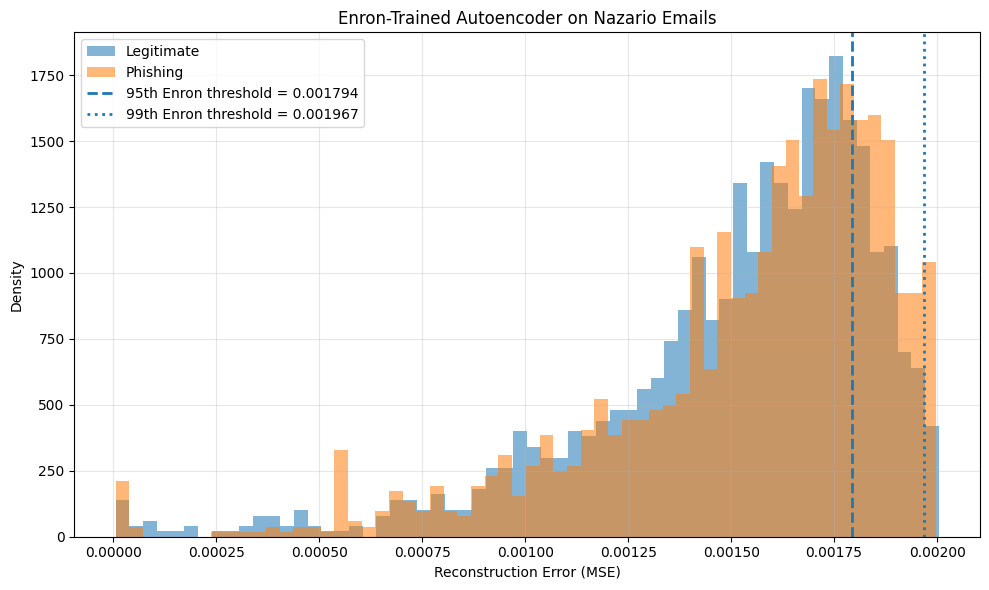

/tmp/ipykernel_561/1373797112.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


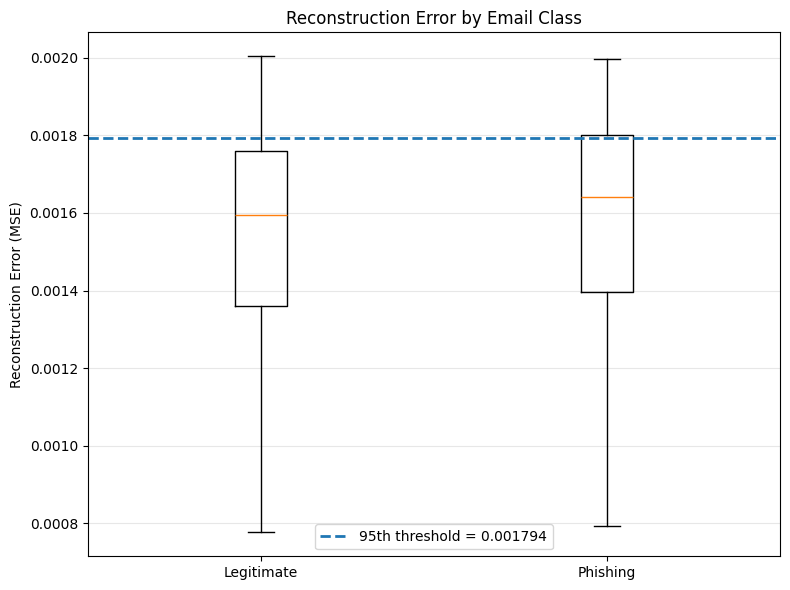

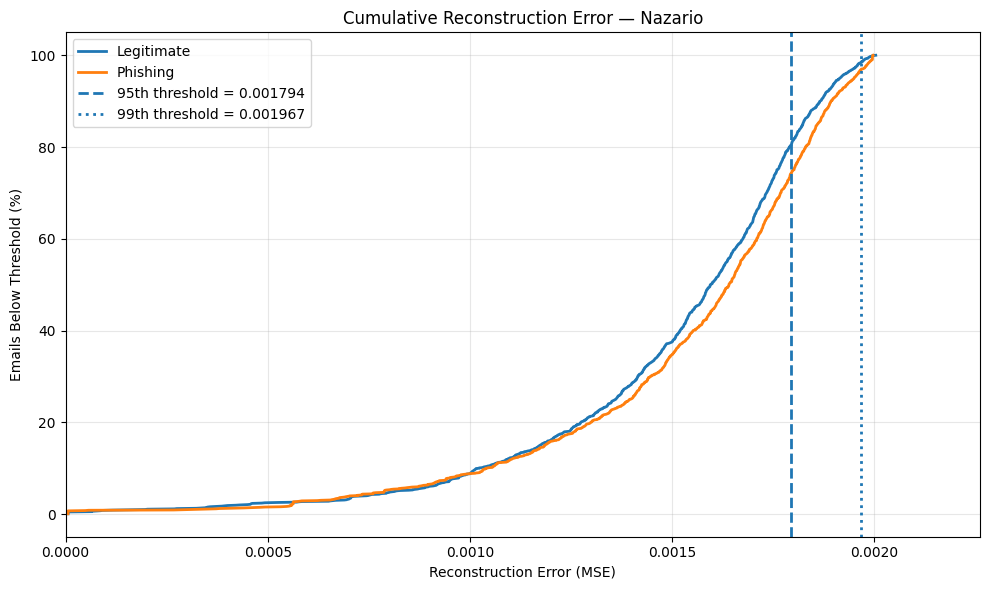


FLAGGING RATE BY CLASS

90th percentile threshold (0.001693)
Legitimate flagged : 37.33%
Phishing flagged   : 42.29%

95th percentile threshold (0.001794)
Legitimate flagged : 19.60%
Phishing flagged   : 25.85%

97th percentile threshold (0.001859)
Legitimate flagged : 10.93%
Phishing flagged   : 15.23%

98th percentile threshold (0.001909)
Legitimate flagged : 5.47%
Phishing flagged   : 8.70%

99th percentile threshold (0.001967)
Legitimate flagged : 1.67%
Phishing flagged   : 3.20%


In [ ]:
# ============================================================
# NAZARIO — RECONSTRUCTION ERROR ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Separate reconstruction errors by class
#
# 0 = legitimate
# 1 = phishing/malicious
# ------------------------------------------------------------

mse_legitimate = mse_nazario[y_true == 0]
mse_phishing = mse_nazario[y_true == 1]

print("=" * 70)
print("RECONSTRUCTION ERROR BY CLASS")
print("=" * 70)

print("\nLEGITIMATE EMAILS")
print(f"Count  : {len(mse_legitimate):,}")
print(f"Mean   : {np.mean(mse_legitimate):.8f}")
print(f"Median : {np.median(mse_legitimate):.8f}")
print(f"Std    : {np.std(mse_legitimate):.8f}")
print(f"Min    : {np.min(mse_legitimate):.8f}")
print(f"Max    : {np.max(mse_legitimate):.8f}")

print("\nPHISHING EMAILS")
print(f"Count  : {len(mse_phishing):,}")
print(f"Mean   : {np.mean(mse_phishing):.8f}")
print(f"Median : {np.median(mse_phishing):.8f}")
print(f"Std    : {np.std(mse_phishing):.8f}")
print(f"Min    : {np.min(mse_phishing):.8f}")
print(f"Max    : {np.max(mse_phishing):.8f}")


# ============================================================
# FIGURE 1 — OVERLAID DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    mse_legitimate,
    bins=60,
    alpha=0.55,
    density=True,
    label="Legitimate"
)

ax.hist(
    mse_phishing,
    bins=60,
    alpha=0.55,
    density=True,
    label="Phishing"
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th Enron threshold = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle=":",
    linewidth=2,
    label=f"99th Enron threshold = {threshold_99:.6f}"
)

ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Density")
ax.set_title(
    "Enron-Trained Autoencoder on Nazario Emails"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — BOX PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [
        mse_legitimate,
        mse_phishing
    ],
    labels=[
        "Legitimate",
        "Phishing"
    ],
    showfliers=False
)

ax.axhline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th threshold = {threshold_95:.6f}"
)

ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title(
    "Reconstruction Error by Email Class"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — CDF BY CLASS
# ============================================================

leg_sorted = np.sort(
    mse_legitimate
)

phish_sorted = np.sort(
    mse_phishing
)

leg_cdf = (
    np.arange(1, len(leg_sorted) + 1)
    / len(leg_sorted)
    * 100
)

phish_cdf = (
    np.arange(1, len(phish_sorted) + 1)
    / len(phish_sorted)
    * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    leg_sorted,
    leg_cdf,
    linewidth=2,
    label="Legitimate"
)

ax.plot(
    phish_sorted,
    phish_cdf,
    linewidth=2,
    label="Phishing"
)

ax.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95th threshold = {threshold_95:.6f}"
)

ax.axvline(
    threshold_99,
    linestyle=":",
    linewidth=2,
    label=f"99th threshold = {threshold_99:.6f}"
)

ax.set_xlabel(
    "Reconstruction Error (MSE)"
)

ax.set_ylabel(
    "Emails Below Threshold (%)"
)

ax.set_title(
    "Cumulative Reconstruction Error — Nazario"
)

ax.set_xlim(
    0,
    max(
        threshold_99 * 1.15,
        np.percentile(mse_nazario, 99.5)
    )
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 4 — FLAGGING RATE BY CLASS
# ============================================================

print("\n" + "=" * 70)
print("FLAGGING RATE BY CLASS")
print("=" * 70)

for name, threshold in [
    ("90th", threshold_90),
    ("95th", threshold_95),
    ("97th", threshold_97),
    ("98th", threshold_98),
    ("99th", threshold_99)
]:

    legit_flagged = np.mean(
        mse_legitimate > threshold
    ) * 100

    phishing_flagged = np.mean(
        mse_phishing > threshold
    ) * 100

    print(
        f"\n{name} percentile threshold "
        f"({threshold:.6f})"
    )

    print(
        f"Legitimate flagged : "
        f"{legit_flagged:.2f}%"
    )

    print(
        f"Phishing flagged   : "
        f"{phishing_flagged:.2f}%"
    )

In [ ]:
# Core
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Ready.")

Ready.


In [ ]:
# Show useful variables currently in Colab
for name, value in list(globals().items()):
    if name.startswith("_"):
        continue

    try:
        if isinstance(value, (np.ndarray, pd.DataFrame, pd.Series, list)):
            print(
                f"{name:40s} | "
                f"type={type(value).__name__:12s} | "
                f"shape={getattr(value, 'shape', None)}"
            )
    except:
        pass

In                                       | type=list         | shape=None
subdirectory                             | type=list         | shape=None
filenames                                | type=list         | shape=None
X_val_nlp                                | type=ndarray      | shape=(49455, 500)
reconstructions_nlp                      | type=ndarray      | shape=(49455, 500)
mse_nlp                                  | type=ndarray      | shape=(49455,)
sorted_mse                               | type=ndarray      | shape=(49455,)
cumulative_percentage                    | type=ndarray      | shape=(49455,)
percentiles                              | type=ndarray      | shape=(20,)
threshold_values                         | type=ndarray      | shape=(20,)
flagging_rates                           | type=list         | shape=None
dirs                                     | type=list         | shape=None
files                                    | type=list         | shape=None
email_df

In [ ]:
# Show trained ML / neural-network objects
for name, value in list(globals().items()):
    if name.startswith("_"):
        continue

    cls = type(value).__name__

    if any(x in cls.lower() for x in [
        "model", "autoencoder", "classifier", "tokenizer",
        "vectorizer", "scaler"
    ]):
        print(name, "->", cls)

tfidf -> TfidfVectorizer


In [ ]:
import numpy as np
import pandas as pd

print("texts       :", len(texts))
print("y_true      :", len(y_true))
print("mse_nazario :", len(mse_nazario))

assert len(texts) == len(y_true) == len(mse_nazario)

print("\nLabels:")
print(np.unique(y_true, return_counts=True))

print("\nMSE:")
print("min :", mse_nazario.min())
print("max :", mse_nazario.max())
print("mean:", mse_nazario.mean())

texts       : 3063
y_true      : 3063
mse_nazario : 3063

Labels:
(array([0, 1]), array([1500, 1563]))

MSE:
min : 5.8025466e-06
max : 0.0020041864
mean: 0.0015274659


In [ ]:
data = pd.DataFrame({
    "text": texts.astype(str).values,
    "label": np.asarray(y_true).astype(int),
    "mse": np.asarray(mse_nazario).astype(float)
})

print(data.shape)
display(data.head())

(3063, 3)


,text,label,mse
0,user id: enrondlr pw: bnaweb22 -----original m...,0,0.001623
1,"hi chris, tonight we are rolling out a new rep...",0,0.001600
2,rika r these new? -----original message----- f...,0,0.001340
3,"john/gerald, we are currently trading under gt...",0,0.001403
4,gerald and stacy - attached is a worksheet for...,0,0.001052


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train: (2450, 3)
Test : (613, 3)

Train labels:
label
1    1250
0    1200
Name: count, dtype: int64

Test labels:
label
1    313
0    300
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_model = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_text = tfidf_model.fit_transform(
    train_df["text"]
)

X_test_text = tfidf_model.transform(
    test_df["text"]
)

print("Training TF-IDF:", X_train_text.shape)
print("Testing TF-IDF :", X_test_text.shape)

Training TF-IDF: (2450, 30000)
Testing TF-IDF : (613, 30000)


In [ ]:
from sklearn.preprocessing import StandardScaler

mse_scaler = StandardScaler()

mse_train = mse_scaler.fit_transform(
    train_df[["mse"]]
)

mse_test = mse_scaler.transform(
    test_df[["mse"]]
)

print("Scaled MSE train:", mse_train.shape)
print("Scaled MSE test :", mse_test.shape)

Scaled MSE train: (2450, 1)
Scaled MSE test : (613, 1)


In [ ]:
from scipy.sparse import hstack, csr_matrix

X_train = hstack([
    X_train_text,
    csr_matrix(mse_train)
]).tocsr()

X_test = hstack([
    X_test_text,
    csr_matrix(mse_test)
]).tocsr()

y_train = train_df["label"].values
y_test = test_df["label"].values

print("Final train shape:", X_train.shape)
print("Final test shape :", X_test.shape)

Final train shape: (2450, 30001)
Final test shape : (613, 30001)


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    C=2.0,
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

clf.fit(X_train, y_train)

print("Training complete.")

Training complete.


In [ ]:
test_prob = clf.predict_proba(X_test)[:, 1]

print("Probability statistics")
print("----------------------")
print("Min :", test_prob.min())
print("25% :", np.percentile(test_prob, 25))
print("50% :", np.percentile(test_prob, 50))
print("75% :", np.percentile(test_prob, 75))
print("Max :", test_prob.max())

Probability statistics
----------------------
Min : 0.005309888540730134
25% : 0.0750167099477802
50% : 0.5634273654517936
75% : 0.9339131740622508
Max : 0.9981430116721357


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

pred_default = (test_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    pred_default,
    target_names=["Legitimate", "Phishing"],
    digits=4
))

print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("PR-AUC  :", average_precision_score(y_test, test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_default))

              precision    recall  f1-score   support

  Legitimate     0.9933    0.9833    0.9883       300
    Phishing     0.9842    0.9936    0.9889       313

    accuracy                         0.9886       613
   macro avg     0.9887    0.9885    0.9886       613
weighted avg     0.9886    0.9886    0.9886       613

ROC-AUC : 0.9989989350372737
PR-AUC  : 0.999027439406484

Confusion Matrix:
[[295   5]
 [  2 311]]


In [ ]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:

    pred = (test_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,

        "recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_test,
            pred,
            zero_division=0
        ),

        "accuracy": accuracy_score(
            y_test,
            pred
        ),

        # False-positive rate among legitimate emails
        "false_positive_rate": (
            pred[y_test == 0].mean()
        )
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

,threshold,recall,precision,f1,accuracy,false_positive_rate
0,0.01,1.000000,0.512275,0.677489,0.513866,0.993333
1,0.02,1.000000,0.526050,0.689427,0.539967,0.940000
2,0.03,1.000000,0.548161,0.708145,0.579119,0.860000
3,0.04,1.000000,0.580705,0.734742,0.631321,0.753333
4,0.05,1.000000,0.614931,0.761557,0.680261,0.653333
...,...,...,...,...,...,...
94,0.95,0.396166,1.000000,0.567506,0.691680,0.000000
95,0.96,0.319489,1.000000,0.484262,0.652529,0.000000
96,0.97,0.239617,1.000000,0.386598,0.611746,0.000000
97,0.98,0.134185,1.000000,0.236620,0.557912,0.000000


In [ ]:
targets = [
    0.80,
    0.85,
    0.90,
    0.92,
    0.95,
    0.97,
    0.98,
    0.99
]

summary = []

for target in targets:

    candidates = threshold_results[
        threshold_results["recall"] >= target
    ]

    if len(candidates) == 0:
        continue

    # Among thresholds meeting the recall target,
    # select the one with highest precision.
    best = candidates.sort_values(
        ["precision", "f1"],
        ascending=False
    ).iloc[0]

    summary.append({
        "Target Recall": target,
        "Threshold": best["threshold"],
        "Actual Recall": best["recall"],
        "Precision": best["precision"],
        "F1": best["f1"],
        "False Positive Rate": best["false_positive_rate"]
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Target Recall,Threshold,Actual Recall,Precision,F1,False Positive Rate
0,0.80,0.71,0.920128,1.000000,0.958403,0.000000
1,0.85,0.71,0.920128,1.000000,0.958403,0.000000
2,0.90,0.71,0.920128,1.000000,0.958403,0.000000
3,0.92,0.71,0.920128,1.000000,0.958403,0.000000
4,0.95,0.60,0.952077,0.990033,0.970684,0.010000
5,0.97,0.53,0.974441,0.987055,0.980707,0.013333
6,0.98,0.40,0.996805,0.984227,0.990476,0.016667
7,0.99,0.40,0.996805,0.984227,0.990476,0.016667


In [ ]:
TARGET_RECALL = 0.95

candidates = threshold_results[
    threshold_results["recall"] >= TARGET_RECALL
]

if len(candidates) == 0:
    raise RuntimeError(
        "The classifier could not achieve the requested recall."
    )

best = candidates.sort_values(
    ["precision", "f1"],
    ascending=False
).iloc[0]

FINAL_THRESHOLD = float(best["threshold"])

print("=" * 60)
print("SELECTED PHISHING DETECTION THRESHOLD")
print("=" * 60)

print(f"Target recall       : {TARGET_RECALL:.1%}")
print(f"Threshold           : {FINAL_THRESHOLD:.4f}")
print(f"Actual recall       : {best['recall']:.2%}")
print(f"Precision           : {best['precision']:.2%}")
print(f"F1                  : {best['f1']:.2%}")
print(f"False positive rate : {best['false_positive_rate']:.2%}")

SELECTED PHISHING DETECTION THRESHOLD
Target recall       : 95.0%
Threshold           : 0.6000
Actual recall       : 95.21%
Precision           : 99.00%
F1                  : 97.07%
False positive rate : 1.00%


In [ ]:
final_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(int)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

              precision    recall  f1-score   support

  Legitimate     0.9519    0.9900    0.9706       300
    Phishing     0.9900    0.9521    0.9707       313

    accuracy                         0.9706       613
   macro avg     0.9710    0.9710    0.9706       613
weighted avg     0.9714    0.9706    0.9706       613

Confusion Matrix:
[[297   3]
 [ 15 298]]


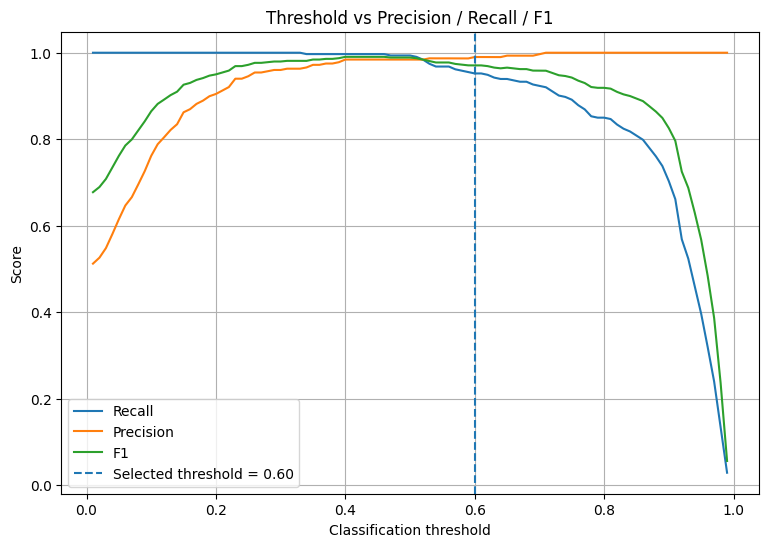

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Selected threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.grid(True)

plt.show()

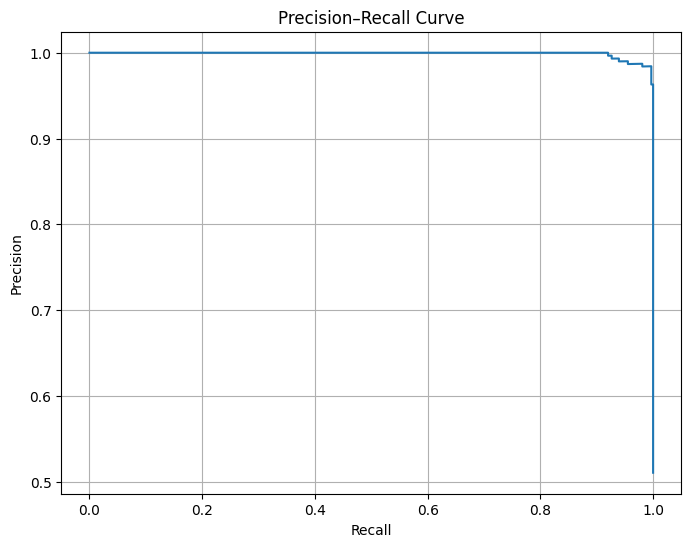

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# First: 80% development, 20% final test
dev_df, final_test_df = train_test_split(
    data,
    test_size=0.20,
    stratify=data["label"],
    random_state=42
)

# Then split development into 75/25
# => 60% total train, 20% total validation
train_df, val_df = train_test_split(
    dev_df,
    test_size=0.25,
    stratify=dev_df["label"],
    random_state=42
)

print("TRAIN :", train_df.shape)
print("VAL   :", val_df.shape)
print("TEST  :", final_test_df.shape)

print("\nClass distributions:")
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVAL")
print(val_df["label"].value_counts())

print("\nTEST")
print(final_test_df["label"].value_counts())

TRAIN : (1837, 3)
VAL   : (613, 3)
TEST  : (613, 3)

Class distributions:
TRAIN
label
1    937
0    900
Name: count, dtype: int64

VAL
label
1    313
0    300
Name: count, dtype: int64

TEST
label
1    313
0    300
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_model = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_text = tfidf_model.fit_transform(
    train_df["text"]
)

X_val_text = tfidf_model.transform(
    val_df["text"]
)

X_test_text = tfidf_model.transform(
    final_test_df["text"]
)

print("Train:", X_train_text.shape)
print("Val  :", X_val_text.shape)
print("Test :", X_test_text.shape)

Train: (1837, 30000)
Val  : (613, 30000)
Test : (613, 30000)


In [ ]:
from sklearn.preprocessing import StandardScaler

mse_scaler = StandardScaler()

mse_train = mse_scaler.fit_transform(
    train_df[["mse"]]
)

mse_val = mse_scaler.transform(
    val_df[["mse"]]
)

mse_test = mse_scaler.transform(
    final_test_df[["mse"]]
)

In [ ]:
from scipy.sparse import hstack, csr_matrix

X_train = hstack([
    X_train_text,
    csr_matrix(mse_train)
]).tocsr()

X_val = hstack([
    X_val_text,
    csr_matrix(mse_val)
]).tocsr()

X_test = hstack([
    X_test_text,
    csr_matrix(mse_test)
]).tocsr()

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = final_test_df["label"].values

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (1837, 30001)
Val  : (613, 30001)
Test : (613, 30001)


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    C=2.0,
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

clf.fit(X_train, y_train)

print("Classifier trained.")

Classifier trained.


In [ ]:
val_prob = clf.predict_proba(X_val)[:, 1]

print("Validation probabilities:")
print("Min :", val_prob.min())
print("25% :", np.percentile(val_prob, 25))
print("50% :", np.percentile(val_prob, 50))
print("75% :", np.percentile(val_prob, 75))
print("Max :", val_prob.max())

Validation probabilities:
Min : 0.01545836694285887
25% : 0.0992252024163489
50% : 0.6296498547745722
75% : 0.9265481130057444
Max : 0.9972486930763398


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

val_results = []

for threshold in thresholds:

    pred = (
        val_prob >= threshold
    ).astype(int)

    val_results.append({
        "threshold": threshold,

        "recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),

        "precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_val,
            pred,
            zero_division=0
        ),

        "accuracy": accuracy_score(
            y_val,
            pred
        ),

        "false_positive_rate":
            pred[y_val == 0].mean()
    })

val_results = pd.DataFrame(val_results)

display(
    val_results[
        val_results["recall"] >= 0.90
    ].sort_values(
        "threshold",
        ascending=False
    )
)

,threshold,recall,precision,f1,accuracy,false_positive_rate
76,0.77,0.904153,1.000000,0.949664,0.951060,0.000000
75,0.76,0.913738,1.000000,0.954925,0.955954,0.000000
74,0.75,0.920128,1.000000,0.958403,0.959217,0.000000
73,0.74,0.936102,1.000000,0.966997,0.967374,0.000000
72,0.73,0.936102,1.000000,0.966997,0.967374,0.000000
...,...,...,...,...,...,...
4,0.05,1.000000,0.580705,0.734742,0.631321,0.753333
3,0.04,1.000000,0.553004,0.712173,0.587276,0.843333
2,0.03,1.000000,0.532313,0.694784,0.551387,0.916667
1,0.02,1.000000,0.518212,0.682661,0.525285,0.970000


In [ ]:
TARGET_RECALL = 0.97

candidates = val_results[
    val_results["recall"] >= TARGET_RECALL
]

if len(candidates) == 0:

    raise RuntimeError(
        "Could not achieve the requested recall on validation data."
    )

# Among thresholds achieving target recall,
# choose the one with highest precision.
best = candidates.sort_values(
    ["precision", "f1"],
    ascending=False
).iloc[0]

FINAL_THRESHOLD = float(
    best["threshold"]
)

print("=" * 60)
print("VALIDATION-SELECTED THRESHOLD")
print("=" * 60)

print(
    f"Target recall       : {TARGET_RECALL:.2%}"
)

print(
    f"Threshold           : {FINAL_THRESHOLD:.4f}"
)

print(
    f"Validation recall   : {best['recall']:.2%}"
)

print(
    f"Validation precision: {best['precision']:.2%}"
)

print(
    f"Validation F1       : {best['f1']:.2%}"
)

print(
    f"Validation FPR      : {best['false_positive_rate']:.2%}"
)

VALIDATION-SELECTED THRESHOLD
Target recall       : 97.00%
Threshold           : 0.6300
Validation recall   : 97.12%
Validation precision: 99.35%
Validation F1       : 98.22%
Validation FPR      : 0.67%


In [ ]:
test_prob = clf.predict_proba(X_test)[:, 1]

final_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        final_pred
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            test_prob
        ),
        4
    )
)

print(
    "PR-AUC :",
    round(
        average_precision_score(
            y_test,
            test_prob
        ),
        4
    )
)

FINAL TEST RESULTS
              precision    recall  f1-score   support

  Legitimate     0.9369    0.9900    0.9627       300
    Phishing     0.9899    0.9361    0.9622       313

    accuracy                         0.9625       613
   macro avg     0.9634    0.9631    0.9625       613
weighted avg     0.9639    0.9625    0.9625       613


Confusion Matrix:
[[297   3]
 [ 20 293]]

ROC-AUC: 0.9989
PR-AUC : 0.999
